### Caricamento del Dataset (MayoDataset)
Questa cella definisce una classe personalizzata `MayoDataset` ereditando da `torch.utils.data.Dataset`. Serve per caricare le immagini da una directory, convertirle in scala di grigi (`L`, luminanza), trasformarle in tensori PyTorch (valori in virgola mobile tra 0 e 1) e infine ridimensionarle alla forma desiderata. Alla fine viene istanziato un `DataLoader` per esplorare il dataset a lotti (batch) di 4 immagini per volta, mescolandole casualmente (`shuffle=True`). L'output mostra informazioni sul batch estratto.

In [1]:
import glob

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from PIL import Image
import numpy as np

class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape):
        super().__init__()

        self.data_path = data_path
        self.data_shape = data_shape

        # We expect data_path to be like "./data/Mayo/train" or "./data/Mayo/test"
        self.fname_list = glob.glob(f"{data_path}/*/*.png")

    def __len__(self) -> int:
        return len(self.fname_list)
    
    def __getitem__(self, idx: int): # -> a Tensor of shape (1, H, W), NOT (B, 1, H, W)
        # Load the idx's image from fname_list
        img_path = self.fname_list[idx]


    ##### How to load data from memory and convert to tensor
         # To load the image as grey-scale
        x = Image.open(img_path).convert("L") # L stands for luminance, it's for grey-scale [0-255]
        # Charge in memory the image

        # Resize to the required shape
        # Used to preprocess the data
        # There are three transormations: 
        # 1. Compose: it's used to apply multiple transformations in a sequence
        # 2. ToTensor: it's used to convert the image to a tensor. Takes an array and convert it to a tensor. 
        # 3. Resize: it's used to resize the image to the required shape
        x = transforms.Compose([
            transforms.ToTensor(), # Array -> Tensor -> Convert to float32 -> Normalize in [0,1] -> Shape (1, H, W)
            transforms.Resize(self.data_shape), # (1, n_x, n_y)
        ])(x)
        return x
    #####

    def get_patient_and_slice(self, idx):
        """
        A utility function. Given an idx, it returns the patient ID and the number of slice of
        that patient corresponding to the idx's datapoint.
        """
        fname = self.fname_list[idx]
        patient_id = fname.split('/')[-2]
        slice_n = fname.split('/')[-1]
        return patient_id, slice_n


dataset = MayoDataset(data_path="Mayo/train", data_shape=256)

# Every time we call the loader, it call __getitem__ for each batch
# shuffle=True means that the data will be shuffled every time we call the loader
# batch_size=4 means that the loader will return 4 images at a time. Concatened 4 image  in one dimension
loader = DataLoader(dataset, batch_size=4, shuffle=True) # Creates (B, 1, H, W)

batch = next(iter(loader))
print('Number of patches in the dataset:', len(dataset))
print('Batch tensor shape:', tuple(batch.shape))
print('Batch dtype:', batch.dtype)
print('Batch intensity range:', float(batch.min()), float(batch.max()))

Number of patches in the dataset: 3306
Batch tensor shape: (4, 1, 256, 256)
Batch dtype: torch.float32
Batch intensity range: 0.0 0.9270833730697632


---
### Dimensione del Dataset
Stampiamo a schermo il numero totale di immagini (patch) presenti nel dataset di addestramento appena caricato.

In [2]:
print(len(dataset))

3306


---
### Operazioni Base sui Tensori PyTorch e Autograd
In questo blocco viene mostrato come creare tensori specificando l'opzione `requires_grad=True` per abilitare il calcolo automatico dei gradienti (Autograd). Vengono mostrate operazioni come l'addizione, il prodotto scalare (`@`) e la norma euclidea al quadrato. Chiamando `backward()` sul risultato scalare della norma, PyTorch calcola automaticamente le derivate parziali rispetto al tensore di input `a` e le memorizza in `a.grad`.

In [3]:
import torch

a = torch.tensor([1.0, 3.0, 1.0], requires_grad=True, dtype=torch.float32)
b = torch.tensor([0.0, 1.0, 0.0], dtype=torch.float32)

c = a + b

#scalar product
d = a @ b

# Norm 
norm_a = torch.sum(torch.square(a))  # ||a||_2^2

# Gradient
norm_a.backward()

# The tensor a contains the information of the gradient
print("Sum: ", c)
print("Scalar product: ", d)
print("Norm of a: ", norm_a)
print("Grad: ", a.grad)


Sum:  tensor([1., 4., 1.], grad_fn=<AddBackward0>)
Scalar product:  tensor(3., grad_fn=<DotBackward0>)
Norm of a:  tensor(11., grad_fn=<SumBackward0>)
Grad:  tensor([2., 6., 2.])


---
### Tipi di Dato (Dtypes)
Questo blocco mostra come poter cambiare e convertire il tipo di dato (precisione) di un tensore, ad esempio da float32 a float64 (double) o float16, usando il metodo `.to()`.

In [4]:
print(a.dtype)

a = a.to(torch.float64)
print(a.dtype)

a = a.to(torch.float16)
print(a.dtype)

a = a.to(torch.double)
print(a.dtype)

a = a.to(torch.float)
print(a.dtype)

torch.float32
torch.float64
torch.float16
torch.float64
torch.float32


---
### Creazione di una semplice Rete Neurale (FirstNN)
Definizione di un modello di rete neurale personalizzato creando una classe che estende `nn.Module`. \n
\n
**Dettagli della Rete:**\n
- Nel costruttore (`__init__`) si definiscono tre componenti (livelli):\n
  1. `hidden`: un livello lineare (Fully Connected) che mappa i dati di input da una dimensione `d` a una dimensione interna (Nascosta) `H`. I parametri in questo livello sono i pesi ($W^{(1)}$) e i bias ($b^{(1)}$).\n
  2. `relu`: una funzione di attivazione non lineare (Rectified Linear Unit), essenziale per far apprendere al modello relazioni complesse (funzione $\rho$).\n
  3. `output`: un altro livello lineare che converte le features dalla dimensione `H` a un singolo valore scalare di output (usato per problemi di regressione). I suoi parametri corrispondono a derivati pesi $W^{(2)}$ e bias $b^{(2)}$.\n
- Il metodo `forward(self, x)` spiega come i dati in ingresso `x` (di dimensioni Batch x Input_Dim) passino attraverso i livelli uno dopo l'altro. \n
\n
Nella seconda parte del codice il modello viene istanziato (con input=3 e hidden=32) e testato per la prima volta su un dato simulato non ancora addestrato. La funzione `unsqueeze(0)` viene usata per aggiungere fittiziamente la dimensione di 'batch', passando da un semplice vettore `[3]` a una matrice `[1, 3]`. Le predizioni ottenute saranno casuali in quanto il modello non è stato addestrato.

In [5]:
import torch
import torch.nn as nn # from torch import nn

class FirstNN(nn.Module):
    """ 
    This is a simple neural network with 3 layers: input, hidden and output.
    The input layer has d neurons, the hidden layer has H neurons and the output layer has 1 neuron.
    """
    # Need to define the layers of the model into the constructor
    def __init__(self, d, H): # Constructor with 2 elements: d = input dimension, H = hidden dimension
        
        # Call the constructor of the parent class. Supermethod is used to inherit from the parent class
        super().__init__() 
        
        # Store the input and hidden dimensions
        self.d = d

        # Hidden dimension
        self.H = H

        # Three layer nn:
        # Input layer: that's the input dimension (d)
        # Hidden layer: that's the hidden dimension (H)
        # Output layer: that's the output dimension (1)

        # Initialize the layers of the model with random weights
        self.hidden = nn.Linear(self.d, self.H) # Linear transformation: (W^1, b^1) <-> weights, bias <-> f_{theta^1}
        self.relu = nn.ReLU() # Activation function: (rho)
        self.output = nn.Linear(self.H, 1) # Output layer with 1 neuron (W^2, b^2) <-> f_{theta^2}

    # Need to define the forward pass of the model
    def forward(self, x):
        # Excpects x to be a tensor of the right shape (batch_size, d)

        # x is the input data
        # x is passed through the hidden layer
        z = self.hidden(x) # x is not an image, but a vector (B, d) NOT (B, C, H, W)

        # Then the output of the hidden layer is passed through the activation function
        h = self.relu(z)

        # Finally, the output of the activation function is passed through the output layer
        y = self.output(h)

        # Return the output
        return y

# Test it
x = torch.tensor([1.0, 3.0, 1.0])

# 1. Check if the shape of x is correct
print(x.shape) # Should be (B, d), now is only (d)


x = x.unsqueeze(0) # Add a dimension to x
print(x.shape) # Now is (1, d)

# 2. Check dtype compatibility
# A torch model has float32 dtype by default
print(x.dtype)

# Initialize the model
d = 3
H = 32
model = FirstNN(d, H)
print(model)

# Apply the model to the input data
y_pred = model(x)

# Print the output, it contains random values because the model is not trained yet
print(y_pred)




torch.Size([3])
torch.Size([1, 3])
torch.float32
FirstNN(
  (hidden): Linear(in_features=3, out_features=32, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=32, out_features=1, bias=True)
)
tensor([[0.5247]], grad_fn=<AddmmBackward0>)


---
### Preparazione dei dati Tabellari (Dataset Reale)
Qui si procede con il caricamento di un file CSV (`House_Price.csv`) usando la libreria `pandas`. I dati sono quindi separati in features (`x`, colonne predittive) e target (`y`, colonna 'Price' da predire). Tramite `MinMaxScaler` i dati vengono scalati nel range tra 0 e 1, per evitare che variabili con ordine di grandezza molto diverso destabilizzino l'apprendimento. Infine il tutto è convertito in tensori Float32 di PyTorch.

In [6]:
import torch
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


# Get the DataFrame of the csv data
dataset = pd.read_csv("House_Price.csv")

# Separate features (x) and labels (y)
x = dataset.iloc[:, :-2].values
y = dataset['Price'].values.reshape(-1, 1)

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x = x_scaler.fit_transform(x)
y = y_scaler.fit_transform(y)

# Convert to PyTorch tensor
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

---
### Verifica delle dimensioni
Controllo della grandezza dei tensori creati `x` e `y`. $x$ rappresenta i vari attributi (es. stanze, dimensioni), $y$ è il prezzo corrispondente da stimare.

In [7]:
print(x.shape)
print(y.shape)

torch.Size([4548, 5])
torch.Size([4548, 1])


---
### Inizializzazione della Rete Neurale per il Dataset House Price
Il modello definito in precedenza, `FirstNN`, viene re-inizializzato impostando come dimensione d'ingresso `d=5` per rispecchiare fedelmente il numero di attributi (colonne) del dataset sulle case. Il numero di neuroni nel livello nascosto rimane 32.

In [8]:
# Re-create our model with the right amount of neurons

d = 5
H = 32
model = FirstNN(d, H)

print(model)

FirstNN(
  (hidden): Linear(in_features=5, out_features=32, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=32, out_features=1, bias=True)
)


---
### Creazione DataLoader e Gestione Batch Dataset
I tensori $x$ e $y$ vengono uniti nel formato `TensorDataset`, questo permette a `DataLoader` di raggrupparli assieme e restituire comodamente iterazioni a lotti (batch) di $x_{batch}$ e $y_{batch}$. In questo caso viene usato un `batch_size` di 128 elementi casuali pescati dal dataset.

In [9]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(x, y)

# Every time we iterate over the loader, we get a batch of 128 samples
loader = DataLoader(dataset, batch_size=128, shuffle=True)

xB, yB = next(iter(loader))
print(xB.shape, yB.shape)

torch.Size([128, 5]) torch.Size([128, 1])


---
### Ciclo di Addestramento (Training Loop)
Questo è il cuore dell'apprendimento automatico. \n
\n
**Dettagli dell'Addestramento:**\n
- Viene definita innanzitutto la funzione di costo (Loss Function), in questo problema di regressione si usa la `MSELoss` (Errore Quadratico Medio).\n
- Viene inizializzato l'ottimizzatore, che ha il compito di modificare i pesi. L'esempio usa il metodo della Discesa del Gradiente Stocastica (`SGD`) con fattore di passo (Learning Rate o passo lungo il gradiente) pari a `0.1`. Gli vengono passati i parametri del modello usando `model.parameters()`.\n
- Nel ciclo di scansione sui lotti in `loader` (Epoch), avviene quanto segue:\n
  1. **Forward Pass**: Ai dati del lotto (`xB`) si richiede la predizione del modello, producendo le stime dei prezzi (`y_pred`).\n
  2. **Loss**: Si calcola quant'è distante l'errore commesso dalla rete fra le sue predizioni e i prezzi veri (`yB`).\n
  3. **Backward Pass (`loss.backward()`)**: Propagazione all'indietro. Dato l'errore del modello (loss), PyTorch ricava la derivata del loss rispetto ad ogni singolo peso e bias del modello usando l'algoritmo di autograd. Le derivate restano immagazzinate in memoria nel layer nascosto e in uscita.\n
  4. **Aggiornamento (`optimizer.step()`)**: Ora che conosciamo le pendenze di errore rispetto i pesi del modello, modifichiamo di un piccolo step questi valori provando a ridurre così l'errore.\n
  5. **Reset (`optimizer.zero_grad()`)**: Pulizia della memoria autograd per prepararsi a far ripartire l'algoritmo al giro o lotto seguente. Accumulerebbe i gradienti in caso contrario.

In [10]:
#It's time to train our model

# Use Mean Squared Error
loss_fn = nn.MSELoss()

# Optimizer, takes in input the parameters of the model and the learning rate
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

xB, yB = next(iter(loader)) # we fetch a batch

for(xB, yB) in loader:
    y_pred = model(xB) # ask the model to predict the price of the houses in the batch
    loss = loss_fn(y_pred, yB)

    # Apply the backward - compute the gradient of the loss function
    loss.backward()

    # Update the weights
    optimizer.step()

    # Reset the optimizer
    optimizer.zero_grad()

    print(y_pred[0], yB[0]) # compare the prediction with the actual value
    print(loss)

tensor([0.1339], grad_fn=<SelectBackward0>) tensor([0.5092])
tensor(0.1476, grad_fn=<MseLossBackward0>)
tensor([0.3626], grad_fn=<SelectBackward0>) tensor([0.5599])
tensor(0.0381, grad_fn=<MseLossBackward0>)
tensor([0.3986], grad_fn=<SelectBackward0>) tensor([0.4663])
tensor(0.0202, grad_fn=<MseLossBackward0>)
tensor([0.4987], grad_fn=<SelectBackward0>) tensor([0.6057])
tensor(0.0141, grad_fn=<MseLossBackward0>)
tensor([0.4554], grad_fn=<SelectBackward0>) tensor([0.3568])
tensor(0.0158, grad_fn=<MseLossBackward0>)
tensor([0.4988], grad_fn=<SelectBackward0>) tensor([0.5028])
tensor(0.0164, grad_fn=<MseLossBackward0>)
tensor([0.5569], grad_fn=<SelectBackward0>) tensor([0.6625])
tensor(0.0176, grad_fn=<MseLossBackward0>)
tensor([0.4190], grad_fn=<SelectBackward0>) tensor([0.0877])
tensor(0.0130, grad_fn=<MseLossBackward0>)
tensor([0.5424], grad_fn=<SelectBackward0>) tensor([0.4599])
tensor(0.0135, grad_fn=<MseLossBackward0>)
tensor([0.5009], grad_fn=<SelectBackward0>) tensor([0.5631])
ten

---

In [11]:
import torch
from torch import nn

class SimpleCNN(nn.Module):
    def __init__(self, in_ch, out_ch, n_filters, kernel_size=3):
        super().__init__()

        # Define (convolution) layers -> NOTE: padding="same" means "padded convolution"
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv3 = nn.Conv2d(in_channels=n_filters, out_channels=out_ch, kernel_size=kernel_size, padding="same")

        self.relu = nn.ReLU()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        out = self.conv3(h)
        return out

---

torch.Size([1, 256, 256])
tensor(0.) tensor(0.9018)


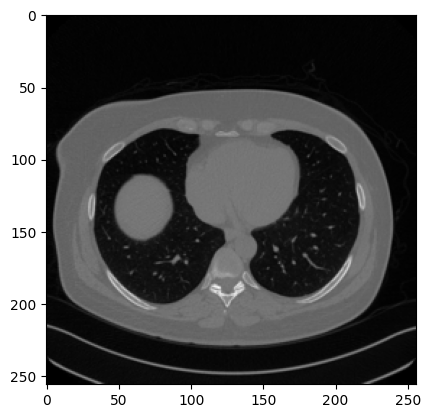

In [ ]:
# Set device
# 3 choice: "cpu", "cuda", "mps"
device = "mps"

# Initializate the dataset
training_dataset = MayoDataset(data_path="Mayo/train", data_shape=256)


x = training_dataset[0]
print(x.shape)
print(x.min(), x.max())

import matplotlib.pyplot as plt
plt.imshow(x.squeeze(), cmap='gray')
plt.show()